Disini merupakan file untuk mengolah data. Akan ada dua jalur, jalur 1 itu untuk model yang based on paper, jalur 2 untuk data yang untuk model custom (buatan kelompok).<br>
Dataset awalnya akan di download dari Yahoo Finance, yakni data IHSG (tickernya ^JKSE) dari tanggal 1 Januari 2010 sampai 31 Desember 2025. <br>
Lalu, data tersebut disimpan di data\raw\ihsg_raw_20100101_20251231.csv <br>
<br>
Nah, data raw ini terdiri dari date, open, high, low, close, dan volume, disingkat menjadi OHLCV <br>
Data raw berjumlah 3886 baris.<br>
Data yang dari Yahoo itu exclude tanggal merah dan hari libur, makanya jika kita buka data raw csv nya, datanya start dari 2010-1-4. Karena 2010-1-1 (tanggal merah), 2010-1-2 (sabtu), dan 2010-1-3 (minggu).

### Download Data (Yahoo Finance)

In [33]:
import os
import yfinance as yf
import pandas as pd
import glob
import numpy as np
from ta.trend import EMAIndicator, SMAIndicator, MACD
from ta.momentum import RSIIndicator

ticker = "^JKSE"
start_date = "2010-01-01"
end_date = "2025-12-31"

print(f"=== Mengunduh Data {ticker} ===")
df_raw = yf.download(ticker, start=start_date, end=end_date)
if df_raw.empty:
    print("Error: Data tidak ditemukan.")
else:
    output_dir = os.path.join("..", "data", "raw")
    os.makedirs(output_dir, exist_ok=True)
    filename = f"ihsg_raw_{start_date.replace('-', '')}_{end_date.replace('-', '')}.csv"
    file_path = os.path.join(output_dir, filename)
    df_raw.to_csv(file_path)
    print(f"Data mentah disimpan di: {file_path}")


[*********************100%***********************]  1 of 1 completed

=== Mengunduh Data ^JKSE ===
Data mentah disimpan di: ..\data\raw\ihsg_raw_20100101_20251231.csv


# **Data Preparation for Paper Based Models**

### **Feature Engineering**

Nah, di paper itu author menggunakan 7 indikator (EMA 9, SMA 5, SMA 15, SMA 30, RSI, MACD, dan MACD Signal). <br>
Author mau memprediksi harga besok, sehingga next row di shift ke bawah satu hari, lalu close price nya di add ke row itu, sehingga sekarang itu ada kolom close, dan kolom target close. <br>
Perhatikan bahwa beberapa fitur itu butuh data beberapa hari ke belakang, sehingga beberapa hari yang ada di awal data akan tidak digunakan karena datanya tidak cukup.<br>
Pada akhirnya, datanya tersisa 3851 baris. <br>
Data hasil process ini akan di simpan di data\processed\ihsg_processed_1.csv

In [ ]:
print("=== Memulai Feature Engineering ===")
raw_path = os.path.join("..", "data", "raw", "ihsg_raw_*.csv")
files = glob.glob(raw_path)
latest_file = max(files, key=os.path.getctime)
print(f"Membaca data dari: {latest_file}")

df = pd.read_csv(latest_file, index_col=0, parse_dates=True, skiprows=[1])
df = df.sort_index()

close_series = df['Close']

df['EMA_9'] = EMAIndicator(close=close_series, window=9).ema_indicator()
df['SMA_5'] = SMAIndicator(close=close_series, window=5).sma_indicator()
df['SMA_15'] = SMAIndicator(close=close_series, window=15).sma_indicator()
df['SMA_30'] = SMAIndicator(close=close_series, window=30).sma_indicator()
df['RSI'] = RSIIndicator(close=close_series, window=14).rsi()

macd_init = MACD(close=close_series, window_fast=12, window_slow=26, window_sign=9)
df['MACD'] = macd_init.macd()
df['MACD_signal'] = macd_init.macd_signal()

df['Target_Close'] = df['Close'].shift(-1)

df_clean = df.dropna()
print(f"Jumlah baris sebelum: {len(df)} -> setelah transformasi: {len(df_clean)}")

processed_dir = os.path.join("..", "data", "processed")
output_path = os.path.join(processed_dir, "ihsg_processed_1.csv")
df_clean.to_csv(output_path)
print(f"Data fitur disimpan di: {output_path}")


=== Memulai Feature Engineering ===
Membaca data dari: ..\data\raw\ihsg_raw_20100101_20251231.csv
Jumlah baris sebelum: 3886 -> setelah transformasi: 3851
Data fitur disimpan di: ..\data\processed\ihsg_processed_1.csv


C:\Users\ThomPC\AppData\Local\Temp\ipykernel_27500\3523728530.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(latest_file, index_col=0, parse_dates=True, skiprows=[1])


### **Correlation Heatmap**

Dari hasil correlation matrix nya, dapat dilihat ada korelasi yang sangat besar. Terutama antara fitur-fitur moving average seperti EMA 9, SMA 5, SMA 15, dan SMA 30. <br>
Lalu juga ada korelasi yang cukup tinggi antara RSI, MACD, dan MACD Signal. <br>

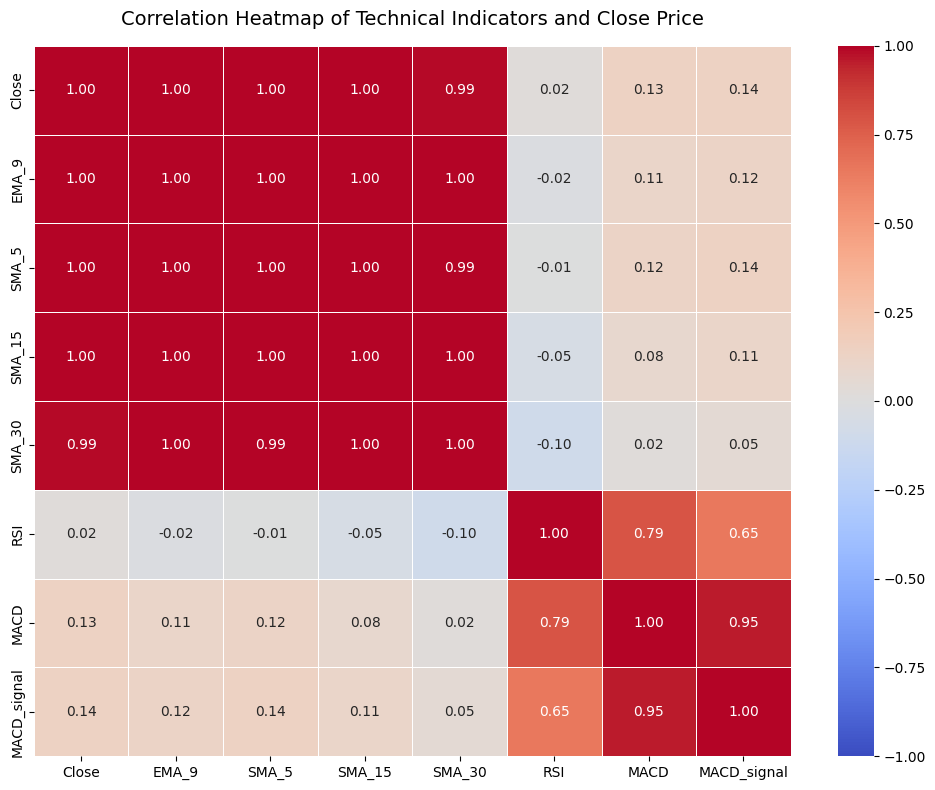

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ['Close', 'EMA_9', 'SMA_5', 'SMA_15', 'SMA_30', 'RSI', 'MACD', 'MACD_signal']
corr_matrix = df[features_to_plot].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)  
plt.title('Correlation Heatmap of Technical Indicators and Close Price', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../outputs/plots/correlation_heatmap_pipeline_1.png')
plt.show()

Untuk jalur 1 ini, akan dibiarkan tetap seperti ini karena tujuan dari jalur 1 ini adalah untuk membuat perbandingan model buatan author paper dan model buatan kelompok kami, sehingga feature engineering nya harus sama persis dengan milik author.

# **Data Preparation for Custom Data**

Pada jalur 2 ini, kelompok kami akan melakukan feature engineering yang berbeda dengan yang dilakukan oleh author.

### **Feature Engineering**

Berikut merupakan detail dari feature apa aja yang dibuat:

- Return_Target: Persentase perubahan harga besok hari. Perbedaannya dengan jalur 1, pada jalur 1 return_target merupakan literally harga hari besok, sedangkan pada jalur 2 ini merupakan persentase dari perubahan harga besok.

- Lag Features:
	- Return_Lag_1: Persentase return hari ini dibanding kemarin. Berfungsi untuk melihat arah pergerakan harga saat ini.
	- Return_Lag_2: Persentase return kemarin dibanding 2 hari lalu.
	- Return_Lag_3: Persentase return 2 hari lalu dibanding 3 hari lalu.
	- Return_Lag_5: Persentase return 4 hari lalu dibanding 5 hari lalu 

- Indikator untuk tren dan momentum harga:
	- RSI_14: Indikator momentum berbasis skala 0–100 yang mengukur kecepatan dan besarnya perubahan pergerakan harga dalam 14 hari terakhir. Mengetahui kondisi jenuh beli (overbought, biasanya >70) yang berpotensi berbalik turun, atau jenuh jual (oversold, biasanya <30) yang berpotensi berbalik naik. 
	
	- MACD_Hist: Selisih antara garis MACD (tren jangka pendek) dengan Garis Sinyal (tren jangka panjang). Mengukur kekuatan momentum tren. Jika nilainya positif dan membesar, artinya tren naik (bullish) sedang menguat. Jika negatif, tren turun (bearish) sedang dominan. 
	
	- Rolling_Mom_5: Total kumulatif return selama 5 hari terakhir. Menangkap momentum jangka pendek (1 minggu perdagangan) untuk melihat apakah pasar sedang dalam mode reli atau koreksi.

- Indikator volatilitas: 
	- Normalized_ATR: Indikator ATR 14 hari (yang mengukur rata-rata jarak High ke Low) dibagi  dengan harga Close saat ini. Mengukur tingkat volatilitas atau "kegaduhan" pasar. Dinormalisasi dengan harga Close agar nilai volatilitas tahun 2010 (saat IHSG masih rendah) bisa setara dan apel-ke-apel jika dibandingkan dengan tahun 2025 (saat IHSG sudah tinggi).

- Vol_to_SMA_20: Rasio antara volume perdagangan hari ini dibagi dengan rata-rata volume 20 hari terakhir. Mendeteksi lonjakan volume perdagangan tidak wajar. Rasio > 1 berarti pasar sedang sangat aktif (sering kali menandakan masuknya uang besar / institusi), sedangkan < 1 menandakan pasar sepi.

- Fitur kalender:
	- Day_of_Week: Angka 0 (Senin) hingga 4 (Jumat). Membantu model mendeteksi anomali seperti Monday Effect (kecenderungan pasar melemah di hari Senin).

	- Is_Month_End: Angka 1 jika hari tersebut adalah akhir bulan, dan 0 jika tidak. Membantu model menangkap pola window dressing atau rebalancing portofolio yang biasa terjadi di akhir bulan.

Data hasil process ini akan di simpan di data\processed\ihsg_processed_2.csv

In [36]:
import ta

raw_path = "../data/raw/ihsg_raw_20100101_20251231.csv"
processed_path = "../data/processed/ihsg_processed_2.csv"

df = pd.read_csv(raw_path, header=0, skiprows=[1, 2])
df.rename(columns={'Price': 'Date'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df['Return_Target'] = df['Close'].pct_change().shift(-1)

df['Return_Lag_1'] = df['Close'].pct_change()
df['Return_Lag_2'] = df['Return_Lag_1'].shift(1)
df['Return_Lag_3'] = df['Return_Lag_1'].shift(2)
df['Return_Lag_5'] = df['Return_Lag_1'].shift(4)

df['RSI_14'] = ta.momentum.rsi(df['Close'], window=14)

df['MACD_Hist'] = ta.trend.macd_diff(df['Close'])

atr_14 = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=14)
df['Normalized_ATR'] = atr_14 / df['Close'] 

sma_vol_20 = ta.trend.sma_indicator(df['Volume'], window=20)
df['Vol_to_SMA_20'] = df['Volume'] / sma_vol_20

df['Rolling_Mom_5'] = df['Return_Lag_1'].rolling(window=5).sum()

df['Day_of_Week'] = df.index.dayofweek
df['Is_Month_End'] = df.index.is_month_end.astype(int)

drop_column = ['Open', 'High', 'Low', 'Volume']
df = df.drop(columns=drop_column)

df_clean = df.dropna()

df_clean.to_csv(processed_path)

print("Data berhasil diproses menggunakan library 'ta'!")
print(f"Bentuk akhir dataset: {df_clean.shape}")
print(f"Tersimpan di: {processed_path}")

Data berhasil diproses menggunakan library 'ta'!
Bentuk akhir dataset: (3851, 13)
Tersimpan di: ../data/processed/ihsg_processed_2.csv


### **Correlation Heatmap**

Dapat dilihat bahwa korelasi antar fitur nya lumayan rendah. <br>
Ada beberapa fitur yang memiliki korelasi yg lumayan besar, namun karena korelasinya kecil dari 0.7, harusnya masih dalam threshold yang wajar.

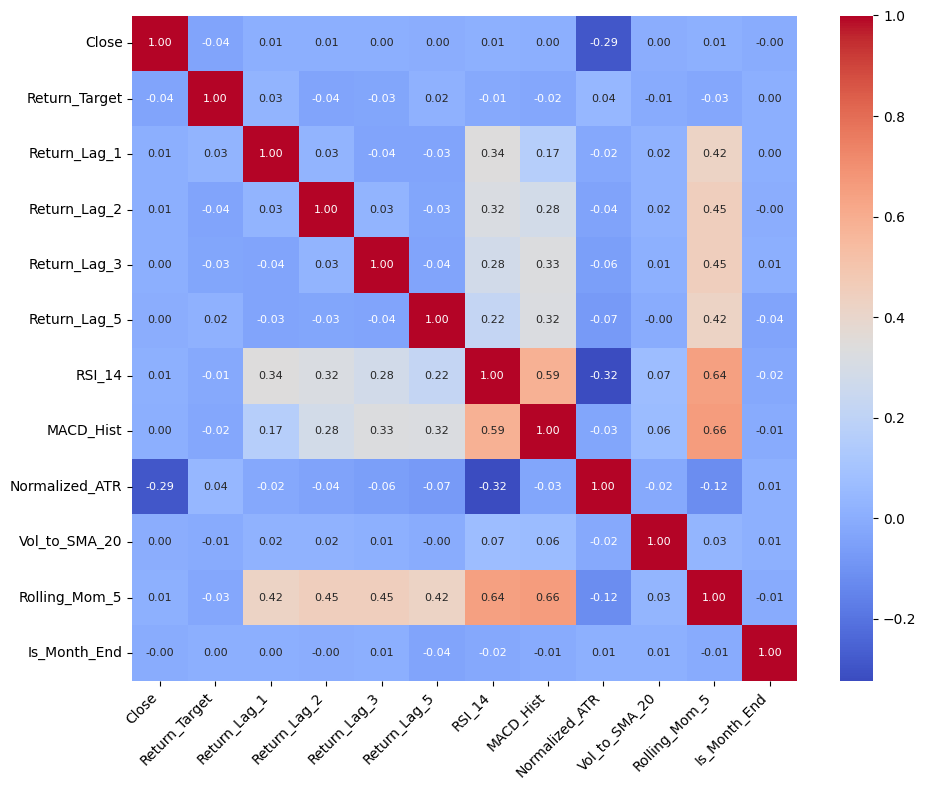

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,       
    fmt=".2f",    
    cmap="coolwarm",    
    ax=ax, 
    annot_kws={"size": 8}, 
    square=True          
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/plots/correlation_heatmap_pipeline_2.png')